# Stats Extension — Robust Regression

This notebook extends the wages analysis from `stats_python.ipynb` by fitting a **robust linear model (RLM)** alongside ordinary least squares (OLS) and comparing both fits on the same plot.


## Setup

Import libraries used for data loading, regression, and visualization.


In [1]:
# Libraries for data handling, statistics, and plotting
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


## Load data

Read wages from `../data/wages.csv` with the same preprocessing as the main notebook.


In [2]:
DATA_DIR = Path("../data").resolve()

# Column names for wages.csv (whitespace-separated, no header row)
WAGES_COLUMNS = [
    "education",
    "south",
    "sex",
    "experience",
    "union",
    "wage",
    "age",
    "race",
    "occupation",
    "sector",
    "marr",
]


def load_wages() -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / "wages.csv",
        sep=r"\s+",
        skiprows=27,  # skip metadata header
        nrows=534,
        header=None,
        names=WAGES_COLUMNS,
        engine="python",
    )
    # Recode sex as strings; log-transform wage for variance stabilization
    df["sex"] = df["sex"].map({0: "Male", 1: "Female"}).astype("string")
    df["wage"] = np.log10(df["wage"])
    return df


In [3]:
wages = load_wages()
display(wages.head())


,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,Female,21,0,0.707570,35,2,6,1,1
1,9,0,Female,42,0,0.694605,57,3,6,1,1
2,12,0,Male,1,0,0.824126,19,3,6,1,0
3,12,0,Male,4,0,0.602060,22,3,6,0,0
4,12,0,Male,17,0,0.875061,35,3,6,0,1


## Compare OLS and RLM

Fit the same model with OLS and robust regression. Both predict log wage from education and sex.


### OLS model

Standard linear regression fit by least squares.


In [4]:
# OLS: log wage ~ education + sex (Female is reference)
wage_model = smf.ols("wage ~ education + C(sex)", data=wages).fit()
print(wage_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        15:43:33   Log-Likelihood:                 86.654
No. Observations:                 534   AIC:                            -167.3
Df Residuals:                     531   BIC:                            -154.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4053      0.046      8.

### Robust regression model

RLM uses Huber's T M-estimator, which down-weights outliers compared to OLS.


In [5]:
# Same formula as OLS, but fit with robust estimation
wage_robust_model = smf.rlm("wage ~ education + C(sex)", data=wages).fit()
print(wage_robust_model.summary())


                    Robust linear Model Regression Results                    
Dep. Variable:                   wage   No. Observations:                  534
Model:                            RLM   Df Residuals:                      531
Method:                          IRLS   Df Model:                            2
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 02 Jul 2026                                         
Time:                        15:43:34                                         
No. Iterations:                    15                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3936      0.047      8.

### Overlay fitted lines

Plot observed wages against education, with solid OLS and dashed RLM lines for each sex.


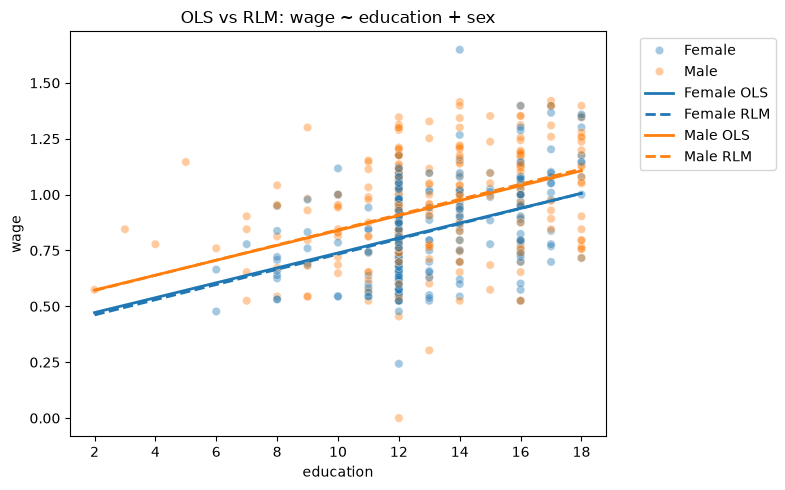

In [6]:
# Build prediction grid across the education range for both sex groups
edu_range = np.linspace(wages["education"].min(), wages["education"].max(), 100)
pred_grid = pd.DataFrame(
    {
        "education": np.tile(edu_range, 2),
        "sex": np.repeat(["Female", "Male"], len(edu_range)),
    }
)
pred_grid["ols_pred"] = wage_model.predict(pred_grid)
pred_grid["rlm_pred"] = wage_robust_model.predict(pred_grid)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=wages, x="education", y="wage", hue="sex", alpha=0.4, ax=ax)

# Match line colors to scatter hue colors
palette = dict(zip(["Female", "Male"], sns.color_palette(n_colors=2)))
for sex in ["Female", "Male"]:
    subset = pred_grid[pred_grid["sex"] == sex]
    ax.plot(
        subset["education"],
        subset["ols_pred"],
        color=palette[sex],
        linestyle="-",
        linewidth=2,
        label=f"{sex} OLS",
    )
    ax.plot(
        subset["education"],
        subset["rlm_pred"],
        color=palette[sex],
        linestyle="--",
        linewidth=2,
        label=f"{sex} RLM",
    )

ax.set_title("OLS vs RLM: wage ~ education + sex")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
